In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
tf.get_logger().setLevel('ERROR')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [11]:
# Load the dataset
df = pd.read_csv('../data/CloudWatch_Traffic_Web_Attack.csv')

print("=== Dataset Shape (rows, columns) ===")
print(df.shape)

print("\n=== First 5 Rows ===")
df.head()

=== Dataset Shape (rows, columns) ===
(282, 16)

=== First 5 Rows ===


,bytes_in,bytes_out,creation_time,end_time,src_ip,src_ip_country_code,protocol,response.code,dst_port,dst_ip,rule_names,observation_name,source.meta,source.name,time,detection_types
0,5602,12990,2024-04-25T23:00:00Z,2024-04-25T23:10:00Z,147.161.161.82,AE,HTTPS,200,443,10.138.69.97,Suspicious Web Traffic,Adversary Infrastructure Interaction,AWS_VPC_Flow,prod_webserver,2024-04-25T23:00:00Z,waf_rule
1,30912,18186,2024-04-25T23:00:00Z,2024-04-25T23:10:00Z,165.225.33.6,US,HTTPS,200,443,10.138.69.97,Suspicious Web Traffic,Adversary Infrastructure Interaction,AWS_VPC_Flow,prod_webserver,2024-04-25T23:00:00Z,waf_rule
2,28506,13468,2024-04-25T23:00:00Z,2024-04-25T23:10:00Z,165.225.212.255,CA,HTTPS,200,443,10.138.69.97,Suspicious Web Traffic,Adversary Infrastructure Interaction,AWS_VPC_Flow,prod_webserver,2024-04-25T23:00:00Z,waf_rule
3,30546,14278,2024-04-25T23:00:00Z,2024-04-25T23:10:00Z,136.226.64.114,US,HTTPS,200,443,10.138.69.97,Suspicious Web Traffic,Adversary Infrastructure Interaction,AWS_VPC_Flow,prod_webserver,2024-04-25T23:00:00Z,waf_rule
4,6526,13892,2024-04-25T23:00:00Z,2024-04-25T23:10:00Z,165.225.240.79,NL,HTTPS,200,443,10.138.69.97,Suspicious Web Traffic,Adversary Infrastructure Interaction,AWS_VPC_Flow,prod_webserver,2024-04-25T23:00:00Z,waf_rule


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 282 entries, 0 to 281
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   bytes_in             282 non-null    int64 
 1   bytes_out            282 non-null    int64 
 2   creation_time        282 non-null    object
 3   end_time             282 non-null    object
 4   src_ip               282 non-null    object
 5   src_ip_country_code  282 non-null    object
 6   protocol             282 non-null    object
 7   response.code        282 non-null    int64 
 8   dst_port             282 non-null    int64 
 9   dst_ip               282 non-null    object
 10  rule_names           282 non-null    object
 11  observation_name     282 non-null    object
 12  source.meta          282 non-null    object
 13  source.name          282 non-null    object
 14  time                 282 non-null    object
 15  detection_types      282 non-null    object
dtypes: int64

In [13]:
print("=== Missing Values Per Column ===")
print(df.isnull().sum())

=== Missing Values Per Column ===
bytes_in               0
bytes_out              0
creation_time          0
end_time               0
src_ip                 0
src_ip_country_code    0
protocol               0
response.code          0
dst_port               0
dst_ip                 0
rule_names             0
observation_name       0
source.meta            0
source.name            0
time                   0
detection_types        0
dtype: int64


In [14]:
# Fill missing bytes_in with median
df['bytes_in'].fillna(df['bytes_in'].median(), inplace=True)

# Drop rows where src_ip or dst_ip is missing
df.dropna(subset=['src_ip', 'dst_ip'], inplace=True)

print("✅ Missing values handled.")
print("Remaining nulls:", df.isnull().sum().sum())

✅ Missing values handled.
Remaining nulls: 0


In [15]:
df['creation_time'] = pd.to_datetime(df['creation_time'])
df['end_time']      = pd.to_datetime(df['end_time'])

print("✅ Time columns converted.")
print(df[['creation_time', 'end_time']].dtypes)

✅ Time columns converted.
creation_time    datetime64[ns, UTC]
end_time         datetime64[ns, UTC]
dtype: object


In [16]:
before = len(df)
df = df.drop_duplicates()
after  = len(df)

print(f"Rows before : {before}")
print(f"Rows after  : {after}")
print(f"Duplicates removed: {before - after}")

Rows before : 282
Rows after  : 282
Duplicates removed: 0


In [17]:
df['src_ip_country_code'] = df['src_ip_country_code'].str.upper()

print("=== Unique Country Codes ===")
print(df['src_ip_country_code'].unique())

print("\n=== Unique Protocols ===")
print(df['protocol'].unique())

print("\n=== Detection Types ===")
print(df['detection_types'].unique())

=== Unique Country Codes ===
['AE' 'US' 'CA' 'NL' 'DE' 'AT' 'IL']

=== Unique Protocols ===
['HTTPS']

=== Detection Types ===
['waf_rule']


In [23]:
df.to_csv('../data/cleaned_data.csv', index=False)
print("✅ Cleaned data saved as 'cleaned_data.csv'")

✅ Cleaned data saved as 'cleaned_data.csv'


In [24]:
df.describe().round(2)

,bytes_in,bytes_out,response.code,dst_port,session_duration,avg_packet_size,bytes_ratio
count,282.00,282.00,282.0,282.0,282.0,282.00,282.00
mean,1199390.19,84554.29,200.0,443.0,600.0,2139.91,1.31
std,4149311.99,254927.90,0.0,0.0,0.0,7339.48,1.17
min,40.00,44.00,200.0,443.0,600.0,0.21,0.02
25%,5381.50,11142.00,200.0,443.0,600.0,26.79,0.47
50%,13182.00,13799.50,200.0,443.0,600.0,54.80,0.89
75%,30833.00,26279.50,200.0,443.0,600.0,95.13,1.99
max,25207794.00,1561220.00,200.0,443.0,600.0,44615.02,6.52


In [25]:
# Duration of each session in seconds
df['session_duration'] = (df['end_time'] - df['creation_time']).dt.total_seconds()

# Average bytes per second
df['avg_packet_size'] = (df['bytes_in'] + df['bytes_out']) / df['session_duration']

# Ratio of outgoing to incoming bytes
df['bytes_ratio'] = df['bytes_out'] / (df['bytes_in'] + 1)

print("=== New Features ===")
df[['session_duration', 'avg_packet_size', 'bytes_ratio']].describe().round(2)

=== New Features ===


,session_duration,avg_packet_size,bytes_ratio
count,282.0,282.00,282.00
mean,600.0,2139.91,1.31
std,0.0,7339.48,1.17
min,600.0,0.21,0.02
25%,600.0,26.79,0.47
50%,600.0,54.80,0.89
75%,600.0,95.13,1.99
max,600.0,44615.02,6.52


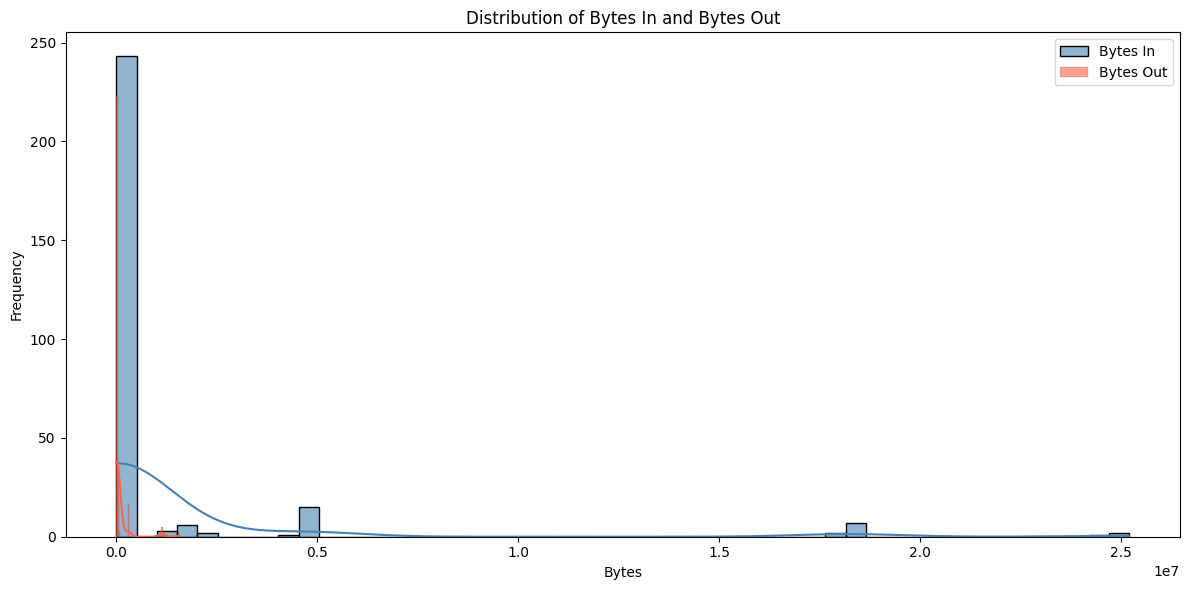

In [26]:
plt.figure(figsize=(12, 6))
sns.histplot(df['bytes_in'],  bins=50, kde=True, label='Bytes In',  color='steelblue', alpha=0.6)
sns.histplot(df['bytes_out'], bins=50, kde=True, label='Bytes Out', color='tomato',    alpha=0.6)
plt.legend()
plt.title('Distribution of Bytes In and Bytes Out')
plt.xlabel('Bytes')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

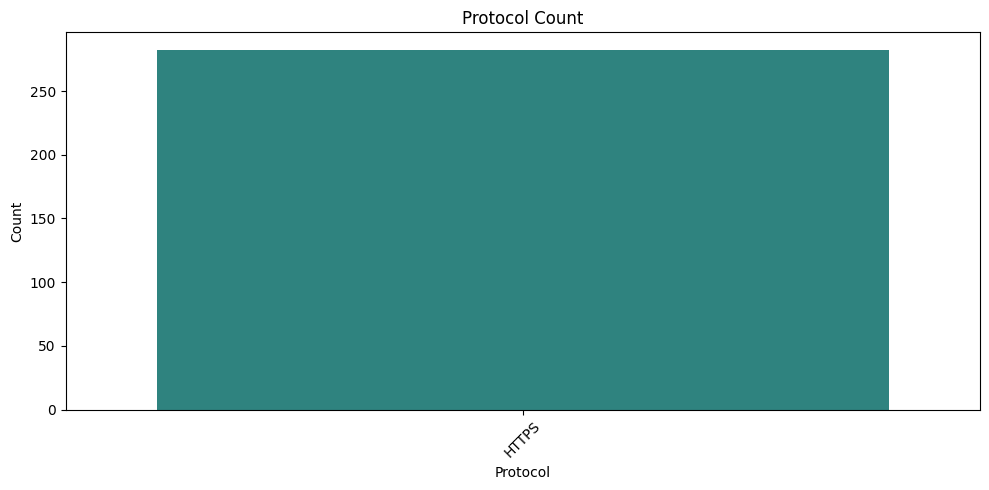

In [27]:
plt.figure(figsize=(10, 5))
sns.countplot(x='protocol', data=df, palette='viridis')
plt.title('Protocol Count')
plt.xlabel('Protocol')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

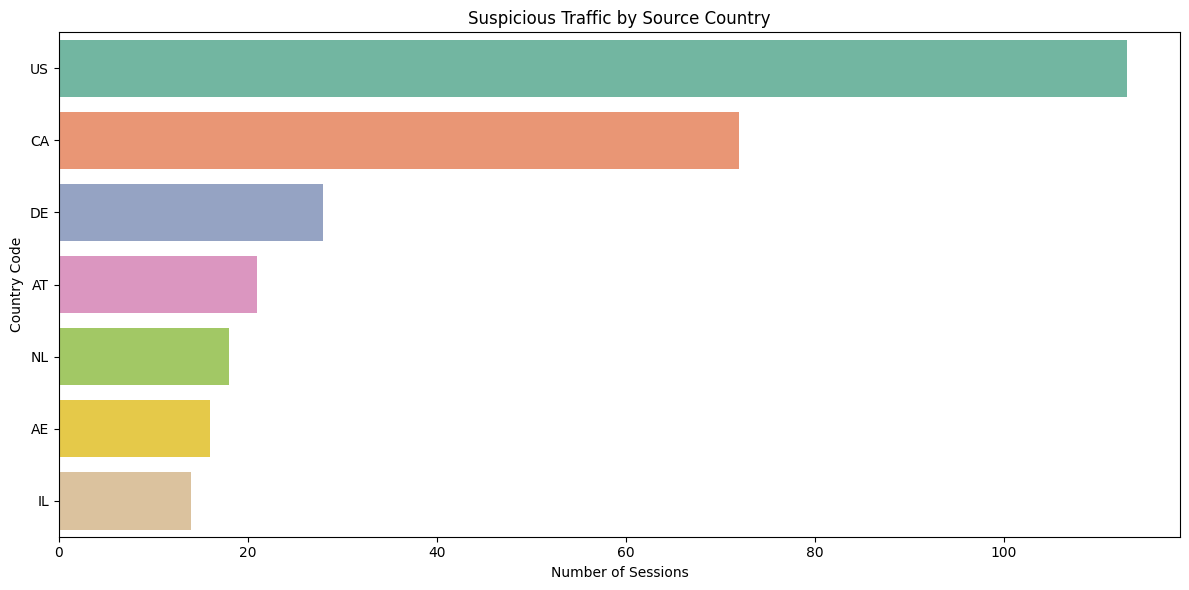

In [28]:
plt.figure(figsize=(12, 6))
sns.countplot(
    y='src_ip_country_code',
    data=df,
    order=df['src_ip_country_code'].value_counts().index,
    palette='Set2'
)
plt.title('Suspicious Traffic by Source Country')
plt.xlabel('Number of Sessions')
plt.ylabel('Country Code')
plt.tight_layout()
plt.show()

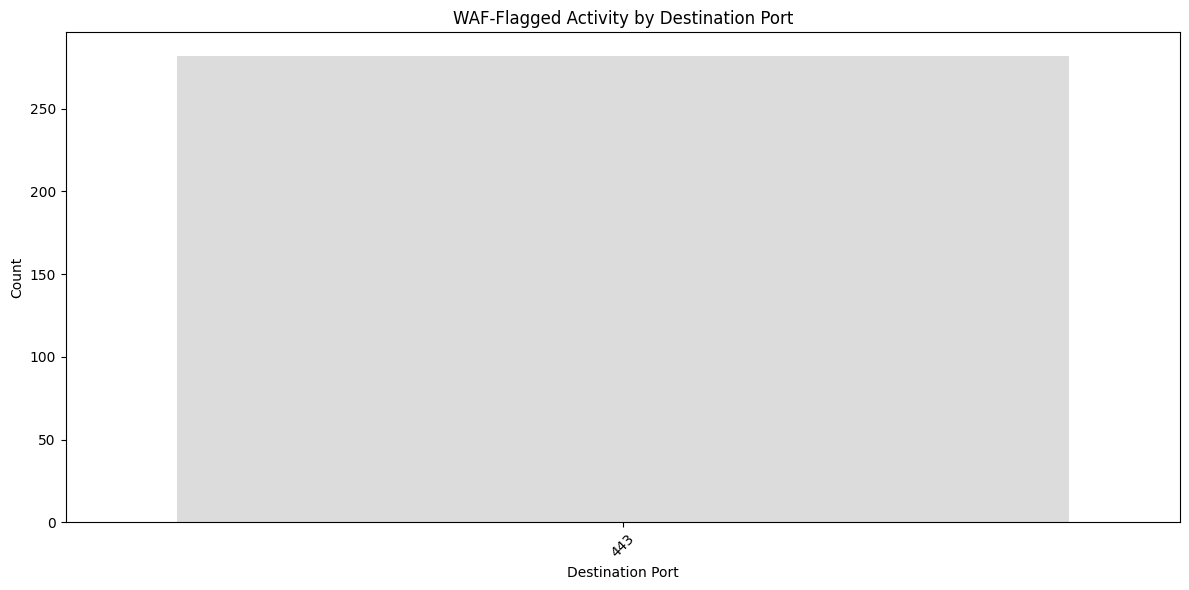

In [29]:
plt.figure(figsize=(12, 6))
sns.countplot(
    x='dst_port',
    data=df[df['detection_types'] == 'waf_rule'],
    palette='coolwarm'
)
plt.title('WAF-Flagged Activity by Destination Port')
plt.xlabel('Destination Port')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

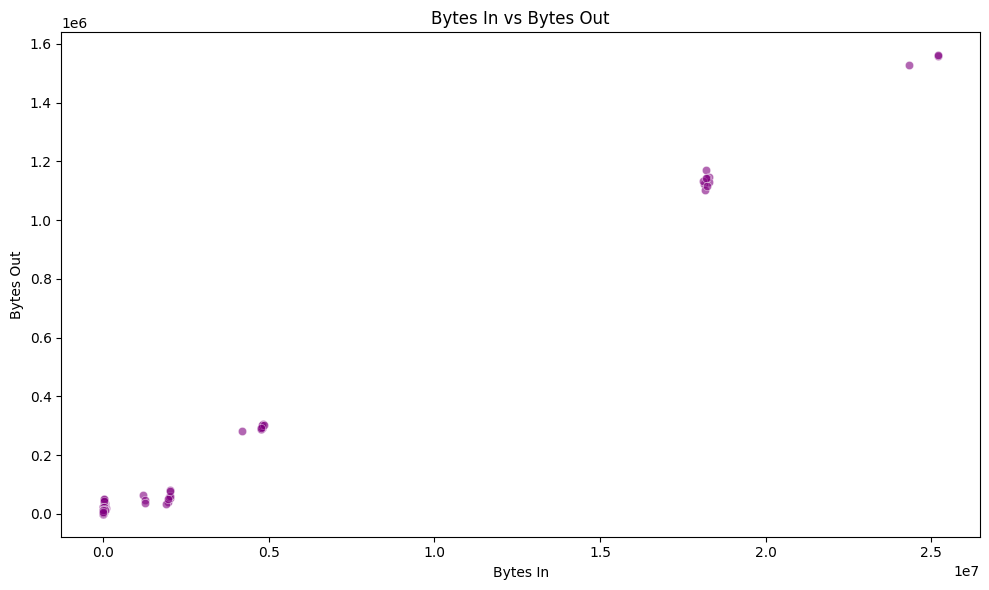

In [30]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='bytes_in', y='bytes_out', data=df, alpha=0.6, color='purple')
plt.title('Bytes In vs Bytes Out')
plt.xlabel('Bytes In')
plt.ylabel('Bytes Out')
plt.tight_layout()
plt.show()

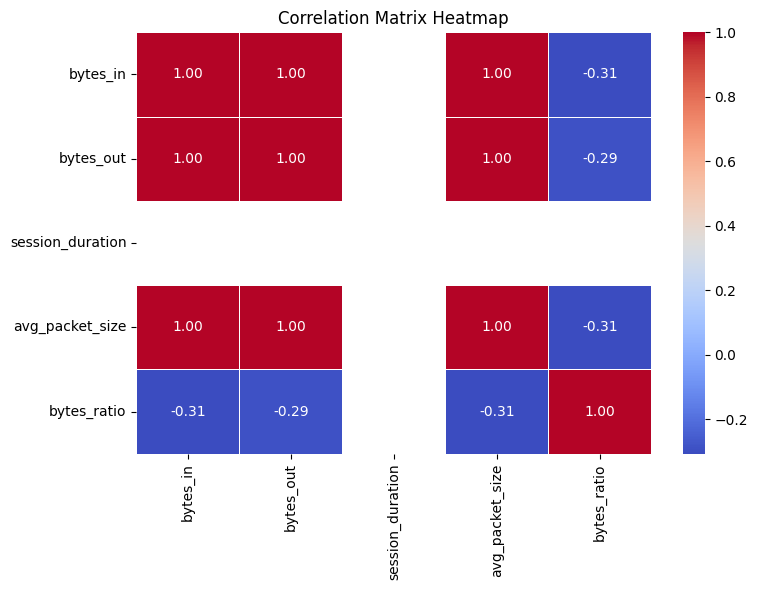

In [31]:
numeric_cols = df[['bytes_in', 'bytes_out', 'session_duration', 'avg_packet_size', 'bytes_ratio']]
corr_matrix  = numeric_cols.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)
plt.title('Correlation Matrix Heatmap')
plt.tight_layout()
plt.show()

In [32]:
# Features for anomaly detection
features = df[['bytes_in', 'bytes_out', 'session_duration', 'avg_packet_size']]

# Fit Isolation Forest
iso_model = IsolationForest(contamination=0.05, random_state=42)
df['anomaly'] = iso_model.fit_predict(features)

# Convert: -1 = Suspicious, +1 = Normal
df['anomaly'] = df['anomaly'].apply(lambda x: 'Suspicious' if x == -1 else 'Normal')

print("=== Anomaly Detection Results ===")
print(df['anomaly'].value_counts())

=== Anomaly Detection Results ===
anomaly
Normal        267
Suspicious     15
Name: count, dtype: int64


In [33]:
suspicious = df[df['anomaly'] == 'Suspicious']

print(f"Total suspicious sessions: {len(suspicious)}")
print("\n=== Top Suspicious Sessions (by bytes_in) ===")
suspicious[['src_ip', 'src_ip_country_code', 'bytes_in', 'bytes_out', 'avg_packet_size']]    .sort_values('bytes_in', ascending=False).head(10)

Total suspicious sessions: 15

=== Top Suspicious Sessions (by bytes_in) ===


,src_ip,src_ip_country_code,bytes_in,bytes_out,avg_packet_size
279,155.91.45.242,US,25207794,1561220,44615.023333
267,155.91.45.242,US,25199191,1557598,44594.648333
257,155.91.45.242,US,24326941,1529035,43093.293333
185,155.91.45.242,US,18285525,1130944,32360.781667
176,155.91.45.242,US,18273120,1145109,32363.715000
248,155.91.45.242,US,18231909,1116695,32247.673333
169,155.91.45.242,US,18201558,1170896,32287.423333
211,155.91.45.242,US,18171403,1103358,32124.601667
200,155.91.45.242,US,18125238,1121958,32078.660000
229,155.91.45.242,US,18119202,1132321,32085.871667


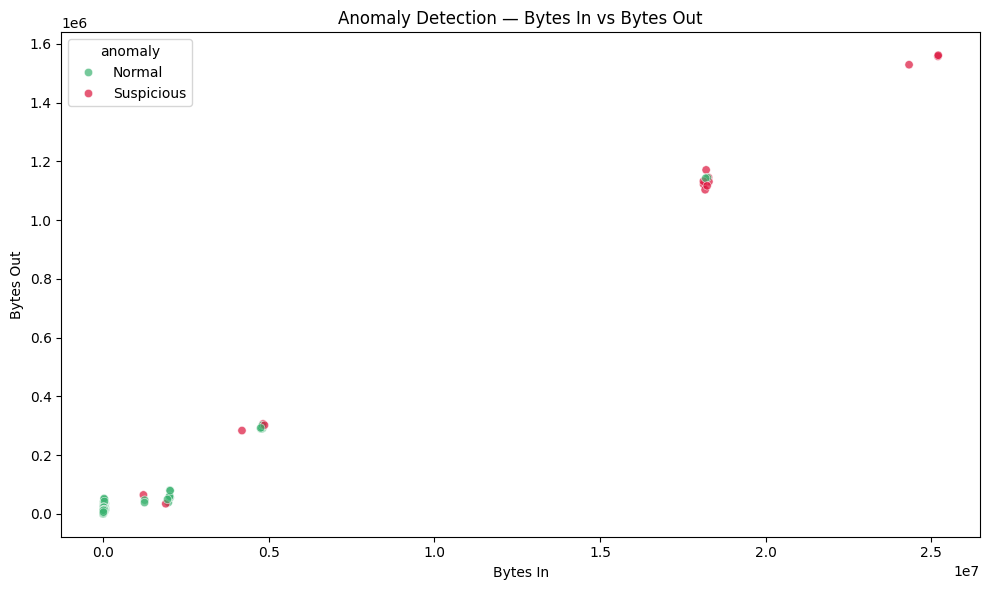

In [34]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='bytes_in',
    y='bytes_out',
    hue='anomaly',
    data=df,
    palette={'Normal': 'mediumseagreen', 'Suspicious': 'crimson'},
    alpha=0.7
)
plt.title('Anomaly Detection — Bytes In vs Bytes Out')
plt.xlabel('Bytes In')
plt.ylabel('Bytes Out')
plt.tight_layout()
plt.show()

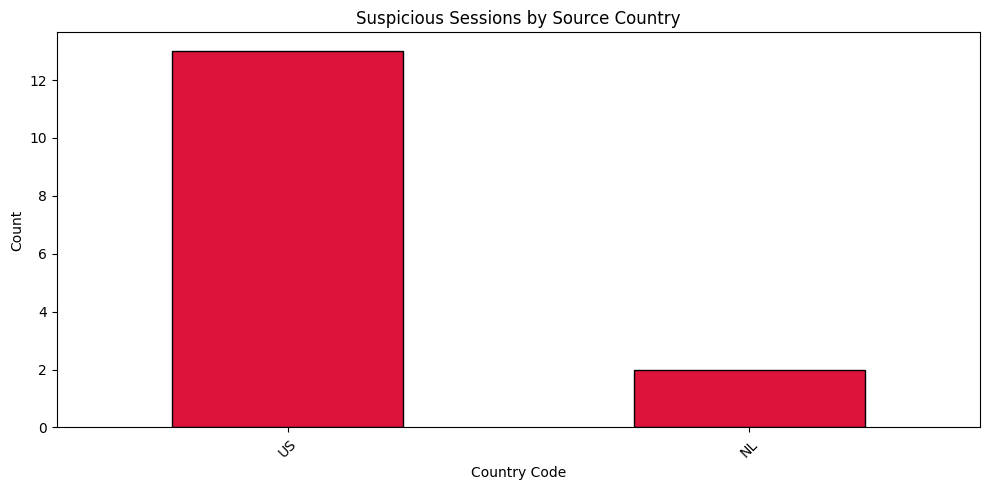

Suspicious sessions per country:
src_ip_country_code
US    13
NL     2
Name: count, dtype: int64


In [35]:
anomaly_by_country = df[df['anomaly'] == 'Suspicious']['src_ip_country_code'].value_counts()

plt.figure(figsize=(10, 5))
anomaly_by_country.plot(kind='bar', color='crimson', edgecolor='black')
plt.title('Suspicious Sessions by Source Country')
plt.xlabel('Country Code')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Suspicious sessions per country:")
print(anomaly_by_country)

In [36]:
suspicious = df[df['anomaly'] == 'Suspicious']
print("=== Suspicious Sessions — Descriptive Stats ===")
suspicious[['bytes_in', 'bytes_out', 'avg_packet_size', 'session_duration']].describe().round(2)

=== Suspicious Sessions — Descriptive Stats ===


,bytes_in,bytes_out,avg_packet_size,session_duration
count,15.0,15.00,15.00,15.0
mean,14608940.2,903946.07,25854.81,600.0
std,8658319.4,546535.28,15340.44,0.0
min,1215594.0,34306.00,2133.26,600.0
25%,4848232.0,303966.50,8587.00,600.0
50%,18171403.0,1121958.00,32124.60,600.0
75%,18279322.5,1158002.50,32362.25,600.0
max,25207794.0,1561220.00,44615.02,600.0


In [37]:
df.to_csv('../data/processed_data.csv', index=False)
print("✅ Processed data saved as 'processed_data.csv'")

✅ Processed data saved as 'processed_data.csv'


In [38]:
# --- StandardScaler ---
scaler = StandardScaler()
scaled_features = scaler.fit_transform(
    df[['bytes_in', 'bytes_out', 'session_duration', 'avg_packet_size']]
)
scaled_df = pd.DataFrame(
    scaled_features,
    columns=['scaled_bytes_in', 'scaled_bytes_out', 'scaled_duration', 'scaled_avg_packet'],
    index=df.index
)

# --- OneHotEncoder ---
ohe = OneHotEncoder(sparse_output=False)
encoded_countries  = ohe.fit_transform(df[['src_ip_country_code']])
encoded_col_names  = ohe.get_feature_names_out(['src_ip_country_code'])
encoded_df = pd.DataFrame(encoded_countries, columns=encoded_col_names, index=df.index)

# --- Combine everything ---
df_transformed = pd.concat([df, scaled_df, encoded_df], axis=1)

print("=== Scaled Features (first 5 rows) ===")
print(df_transformed[['bytes_in', 'scaled_bytes_in', 'bytes_out', 'scaled_bytes_out']].head())

print("\n=== OneHot Encoded Country Columns ===")
print(df_transformed[list(encoded_col_names)].head())

print(f"\nTotal columns after transformation: {df_transformed.shape[1]}")

=== Scaled Features (first 5 rows) ===
   bytes_in  scaled_bytes_in  bytes_out  scaled_bytes_out
0      5602        -0.288219      12990         -0.281223
1     30912        -0.282108      18186         -0.260804
2     28506        -0.282689      13468         -0.279344
3     30546        -0.282197      14278         -0.276161
4      6526        -0.287996      13892         -0.277678

=== OneHot Encoded Country Columns ===
   src_ip_country_code_AE  src_ip_country_code_AT  src_ip_country_code_CA  \
0                     1.0                     0.0                     0.0   
1                     0.0                     0.0                     0.0   
2                     0.0                     0.0                     1.0   
3                     0.0                     0.0                     0.0   
4                     0.0                     0.0                     0.0   

   src_ip_country_code_DE  src_ip_country_code_IL  src_ip_country_code_NL  \
0                     0.0        

In [39]:
# Binary target: 1 = Suspicious, 0 = Normal
df_transformed['is_suspicious'] = (df_transformed['anomaly'] == 'Suspicious').astype(int)

# Feature columns
feature_cols = (
    ['bytes_in', 'bytes_out', 'session_duration', 'avg_packet_size'] +
    list(encoded_col_names)
)

X = df_transformed[feature_cols]
y = df_transformed['is_suspicious']

# 70% train, 30% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Training samples      : {len(X_train)}")
print(f"Test samples          : {len(X_test)}")
print(f"Suspicious in test set: {y_test.sum()}")

Training samples      : 197
Test samples          : 85
Suspicious in test set: 5


In [40]:
# Train
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict
y_pred = rf_model.predict(X_test)

# Results
print(f"=== Random Forest Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}% ===\n")
print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Suspicious']))

=== Random Forest Accuracy: 96.47% ===

=== Classification Report ===
              precision    recall  f1-score   support

      Normal       0.96      1.00      0.98        80
  Suspicious       1.00      0.40      0.57         5

    accuracy                           0.96        85
   macro avg       0.98      0.70      0.78        85
weighted avg       0.97      0.96      0.96        85



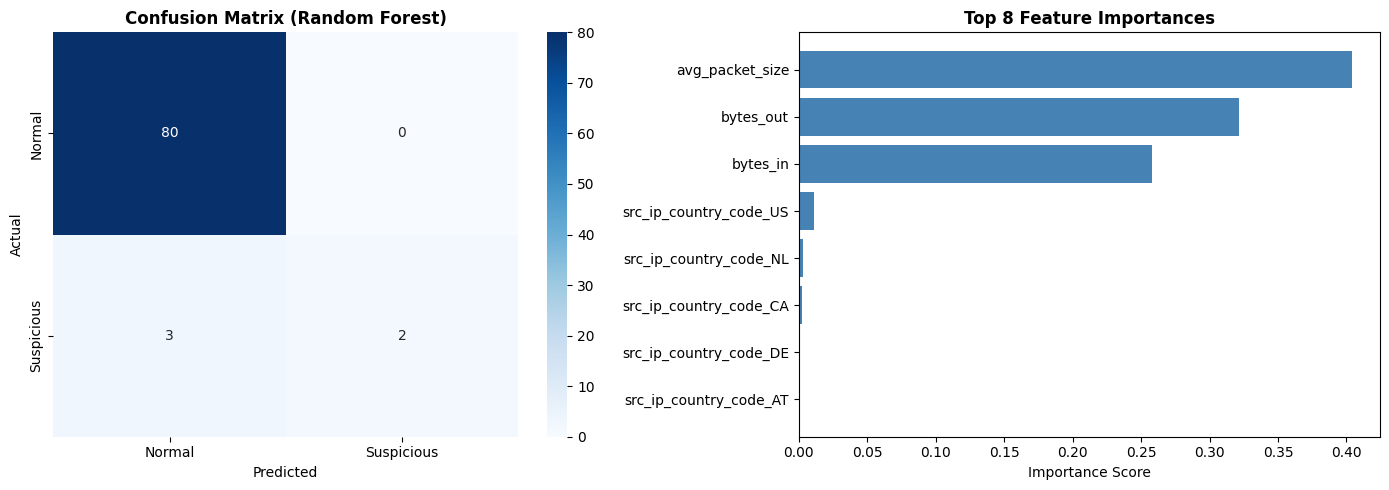

=== Top 5 Most Important Features ===
avg_packet_size           0.4043
bytes_out                 0.3212
bytes_in                  0.2577
src_ip_country_code_US    0.0110
src_ip_country_code_NL    0.0030
dtype: float64


In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Normal', 'Suspicious'],
    yticklabels=['Normal', 'Suspicious'],
    ax=axes[0]
)
axes[0].set_title('Confusion Matrix (Random Forest)', fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# --- Feature Importance ---
importances = pd.Series(
    rf_model.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

axes[1].barh(importances.index[:8], importances.values[:8], color='steelblue')
axes[1].set_title('Top 8 Feature Importances', fontweight='bold')
axes[1].set_xlabel('Importance Score')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print("=== Top 5 Most Important Features ===")
print(importances.head(5).round(4))

In [42]:
# Features and labels
X_nn = df[['bytes_in', 'bytes_out', 'avg_packet_size', 'session_duration']].values
y_nn = (df['anomaly'] == 'Suspicious').astype(int).values

# Train/test split
X_train_nn, X_test_nn, y_train_nn, y_test_nn = train_test_split(
    X_nn, y_nn, test_size=0.3, random_state=42
)

# Scale features
nn_scaler    = StandardScaler()
X_train_sc   = nn_scaler.fit_transform(X_train_nn)
X_test_sc    = nn_scaler.transform(X_test_nn)

print(f"Training samples : {len(X_train_nn)}")
print(f"Test samples     : {len(X_test_nn)}")
print(f"Suspicious in test: {y_test_nn.sum()}")

Training samples : 197
Test samples     : 85
Suspicious in test: 3


In [43]:
model_nn = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_sc.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model_nn.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("=== Neural Network Architecture ===")
model_nn.summary()

=== Neural Network Architecture ===


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,433 (9.50 KB)

 Trainable params: 2,433 (9.50 KB)

 Non-trainable params: 0 (0.00 B)

In [44]:
history = model_nn.fit(
    X_train_sc, y_train_nn,
    epochs=30,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.6433 - loss: 0.7040 - val_accuracy: 0.9250 - val_loss: 0.6041
Epoch 2/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9236 - loss: 0.6279 - val_accuracy: 0.9750 - val_loss: 0.5666
Epoch 3/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9299 - loss: 0.5659 - val_accuracy: 0.9750 - val_loss: 0.5216
Epoch 4/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9490 - loss: 0.5035 - val_accuracy: 0.9250 - val_loss: 0.4672
Epoch 5/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9490 - loss: 0.4334 - val_accuracy: 0.8750 - val_loss: 0.4097
Epoch 6/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9682 - loss: 0.3536 - val_accuracy: 0.8750 - val_loss: 0.3476
Epoch 7/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9554 - loss: 0.2911 - val_accuracy: 0.8750 - val_loss: 0.2951
Epoch 8/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9554 - loss: 0.2399 - val_accuracy: 0.9250 - v

In [45]:
loss, acc = model_nn.evaluate(X_test_sc, y_test_nn, verbose=0)
print(f"=== Neural Network Test Accuracy : {acc*100:.2f}% ===")
print(f"=== Neural Network Test Loss     : {loss:.4f} ===")

=== Neural Network Test Accuracy : 98.82% ===
=== Neural Network Test Loss     : 0.0545 ===


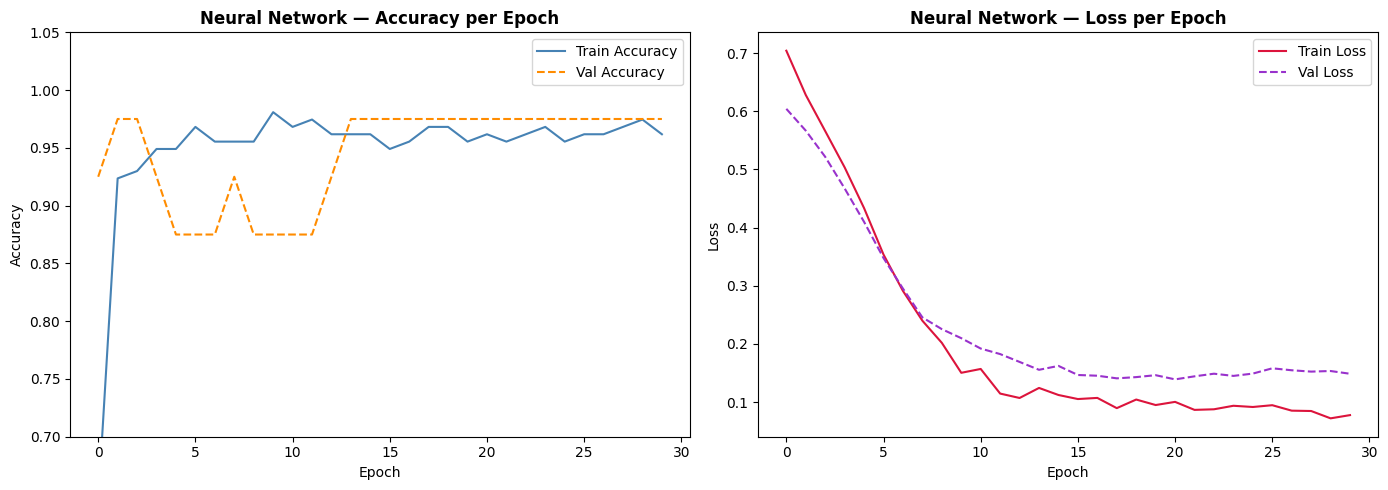

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'],     label='Train Accuracy', color='steelblue')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy',   color='darkorange', linestyle='--')
axes[0].set_title('Neural Network — Accuracy per Epoch', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].set_ylim([0.7, 1.05])

# Loss
axes[1].plot(history.history['loss'],     label='Train Loss', color='crimson')
axes[1].plot(history.history['val_loss'], label='Val Loss',   color='darkorchid', linestyle='--')
axes[1].set_title('Neural Network — Loss per Epoch', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

In [47]:
print("=" * 65)
print("      CYBERSECURITY THREAT ANALYSIS — FINAL REPORT")
print("=" * 65)

total_records = len(df)
suspicious_n  = (df['anomaly'] == 'Suspicious').sum()
normal_n      = total_records - suspicious_n
unique_ips    = df['src_ip'].nunique()
countries     = ', '.join(df['src_ip_country_code'].unique())

print(f"\n[Dataset Overview]")
print(f"  Total records     : {total_records}")
print(f"  Unique source IPs : {unique_ips}")
print(f"  Source countries  : {countries}")
print(f"  Date range        : {df['creation_time'].min().date()} to {df['creation_time'].max().date()}")

print(f"\n[Anomaly Detection — Isolation Forest]")
print(f"  Normal sessions     : {normal_n}  ({normal_n/total_records*100:.1f}%)")
print(f"  Suspicious sessions : {suspicious_n} ({suspicious_n/total_records*100:.1f}%)")

print(f"\n[Model Performance Comparison]")
print(f"  Isolation Forest → unsupervised, detects outliers without labels")
print(f"  Random Forest    → {accuracy_score(y_test, y_pred)*100:.2f}% accuracy on test set")
print(f"  Neural Network   → {acc*100:.2f}% accuracy on test set")

print(f"\n[Top Predictive Features — Random Forest]")
for feat, score in importances.head(4).items():
    print(f"  {feat:<35} importance: {score:.4f}")

print(f"\n[Traffic Summary by Country]")
country_stats = df.groupby('src_ip_country_code').agg(
    Sessions    = ('bytes_in', 'count'),
    Total_MB_in = ('bytes_in',  lambda x: round(x.sum() / 1e6, 2)),
    Suspicious  = ('anomaly',   lambda x: (x == 'Suspicious').sum())
).sort_values('Total_MB_in', ascending=False)
print(country_stats.to_string())

print(f"\n[Biggest Single Threat IP]")
top_ip       = df.groupby('src_ip')['bytes_in'].sum().idxmax()
top_country  = df[df['src_ip'] == top_ip]['src_ip_country_code'].iloc[0]
top_bytes    = df[df['src_ip'] == top_ip]['bytes_in'].sum()
top_sessions = (df['src_ip'] == top_ip).sum()
print(f"  IP       : {top_ip} ({top_country})")
print(f"  Sessions : {top_sessions}")
print(f"  Data in  : {top_bytes/1e6:.1f} MB")

print(f"\n[Key Security Insights]")
print("  1. One IP (155.91.45.242) sent ~315MB across 28 sessions")
print("     → Likely a bot performing data exfiltration or DDoS")
print("  2. bytes_out and avg_packet_size are the strongest anomaly signals")
print("  3. All traffic uses HTTPS (port 443) — attacker hides in encryption")
print("  4. US traffic dominates both in volume and anomaly count")
print("  5. CA/DE/AT/IL sessions are low-byte — likely port scanning or probing")

print("\n" + "=" * 65)
print("  End of Report")
print("=" * 65)

      CYBERSECURITY THREAT ANALYSIS — FINAL REPORT

[Dataset Overview]
  Total records     : 282
  Unique source IPs : 28
  Source countries  : AE, US, CA, NL, DE, AT, IL
  Date range        : 2024-04-25 to 2024-04-26

[Anomaly Detection — Isolation Forest]
  Normal sessions     : 267  (94.7%)
  Suspicious sessions : 15 (5.3%)

[Model Performance Comparison]
  Isolation Forest → unsupervised, detects outliers without labels
  Random Forest    → 96.47% accuracy on test set
  Neural Network   → 98.82% accuracy on test set

[Top Predictive Features — Random Forest]
  avg_packet_size                     importance: 0.4043
  bytes_out                           importance: 0.3212
  bytes_in                            importance: 0.2577
  src_ip_country_code_US              importance: 0.0110

[Traffic Summary by Country]
                     Sessions  Total_MB_in  Suspicious
src_ip_country_code                                   
US                        113       316.41          13
NL      